For each Antarctic drainage basin computes how much warming is
needed before liquid water production (melt+rainfall) reach 70% of net accumulation, and how many CMIP6
models from the selected ensemble (23) get there by 2100 under SSP1-2.6, SSP2-4.5, SSP3-7.0 and SSP5-8.5. 
MAR runs with wind-driven snow (DS/WDS) and without it (nDS/nWDS).

The CMIP6 near-surface temperature archive for scenarios is heavy to upload and to run, so
the notebook works from cached basin means and the archived threshold tables.

### Run modes

`RUN_MODE` 

`figure_only` rebuilds the tables and the figure from `tables/` and `cache/`.
No raw data. it is set by default but you can change the mode,

`cmip6` also recomputes basin warming from the CMIP6 tas (near-surface temperature) archive.
Requires the archive.

`full` also recomputes the MAR thresholds. Needs the MAR
outputs.


In [ ]:
#imports and environment
import os, sys, glob, gc, pickle, platform
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D

print("python     ", sys.version.split()[0])
for _m in (np, pd, mpl):
    print(f"{_m.__name__:11s}", _m.__version__)
try:
    import xarray as xr, geopandas as gpd, pyproj, shapely
    from scipy.optimize import curve_fit
    from shapely.geometry import Point, LineString
    print("xarray     ", xr.__version__)
    print("geopandas  ", gpd.__version__)
    HAVE_GEO = True
except ImportError as _e:
    print("geo/xarray stack unavailable:", _e, "-> figure_only mode only")
    HAVE_GEO = False

python      3.14.1
numpy       2.3.5
pandas      2.3.3
matplotlib  3.10.8
xarray      2025.11.0
geopandas   1.1.2


In [ ]:
#run mode 
RUN_MODE = "figure_only"          #need to choose "figure_only" or "cmip6" or "full"
#input paths (only needed above if figure_only) 
SHP_PATH   = "/Users/dashakan/Downloads/ANT_Basins_IMBIE2_v1.6/ANT_Basins_IMBIE2_v1.6.shp"
TAS_ROOT   = "data/cmip6_tas"     #sub directories: historical/ ssp126/ ssp370/ ssp585/
TAS_ROOT_245 = "data/cmip6_tas_ssp245"   #ssp245 was archived separately bc loaded later
MAR_ROOT   = "data/mar"           #DS and nDS output (with wind-driven snow and without)
#output paths
TAB_DIR, CACHE_DIR, FIG_DIR = "tables", "cache", "figures"
for _d in (TAB_DIR, CACHE_DIR, FIG_DIR):
    os.makedirs(_d, exist_ok=True)
DS_CSV     = "/Users/dashakan/Desktop/scripts_AIS/tables/TMOA_table_350_700m.csv" #these two tables can be computed by running the notebook 'main_figures.ipynb'
NDS_CSV    = "/Users/dashakan/Desktop/scripts_AIS/tables/TMOA_table_nDS_350_700m.csv" 
SECT_CSV   = f"{TAB_DIR}/basin_sector_map.csv"
BT_CACHE   = f"{CACHE_DIR}/basin_tas_18.pkl"
ALL_18 = ["A-Ap", "Ap-B", "B-C", "C-Cp", "Cp-D", "D-Dp", "Dp-E", "E-Ep",
          "Ep-F", "F-G", "G-H", "H-Hp", "Hp-I", "I-Ipp", "Ipp-J", "J-Jpp",
          "Jpp-K", "K-A"]
SCEN4     = ["ssp585", "ssp370", "ssp245", "ssp126"] 
SCEN_LAB  = {"ssp126": "SSP1-2.6", "ssp245": "SSP2-4.5",
             "ssp370": "SSP3-7.0", "ssp585": "SSP5-8.5"}
M_ORDER   = ["CNRM", "IPSL", "MPI", "UKM"]
M_LONG    = {"CNRM": "CNRM-CM6-1", "IPSL": "IPSL-CM6A-LR",
             "MPI": "MPI-ESM1-2-HR", "UKM": "UKESM1-0-LL"}

REF          = (1981, 2010)    
BAND         = (350, 700)         
MOA_CRIT     = 0.7              
SMOOTH_N     = 10              
SUSTAIN_N    = 20                
START_YEAR   = 2015               
HI_YEAR      = 2100


SKIP_MODELS      = ["AWI-CM-1-1-MR", "CAS-ESM2-0", "CanESM5-CanOE",
                   "CMCC-ESM2", "CNRM-CM6-1-HR", "CNRM-ESM2-1"] #these dont open from the loaded ensemble, skip
MEMBER_PRIORITY = ["r1i1p1f1", "r1i1p1f2", "r1i1p2f1", "r1i1p2f2", "r1i1p1f3"]

print("RUN_MODE =", RUN_MODE)

RUN_MODE = figure_only


## Step 1. Basins and sectors

Reads the IMBIE-2 shapefile and puts each basin in East Antarctica, West
Antarctica or the Peninsula. The assignment comes from the shapefile's own
regional field rather than a list typed by hand. In `figure_only` it is read
back from `tables/basin_sector_map.csv`.

In [ ]:
SECT_ORDER = ["EAIS", "WAIS", "AP"]
SECT_FULL  = {"EAIS": "East Antarctica", "WAIS": "West Antarctica",
              "AP": "Antarctic Peninsula"}
SECT_COL   = {"EAIS": "#0072B2", "WAIS": "#D55E00", "AP": "#009E73"}


def _norm_sector(v):
    v = str(v).strip().lower()
    return ("EAIS" if v.startswith("east") else
            "WAIS" if v.startswith("west") else
            "AP" if (v.startswith("pen") or v == "ap") else None)


def build_sector_map():
    """Subregion EAIS/WAIS/AP from the shapefile."""
    gdf = gpd.read_file(SHP_PATH)
    sub = next(c for c in ("Subregion", "SUBREGION", "subregion")
               if c in gdf.columns)
    reg = next(c for c in ("Regions", "Region", "REGION", "regions")
               if c in gdf.columns)
    raw = (gdf.assign(**{sub: gdf[sub].astype(str).str.strip()})
              .groupby(sub)[reg].agg(lambda s: s.mode().iloc[0]))
    m = {b: _norm_sector(v) for b, v in raw.items()}
    m = {b: m[b] for b in ALL_18 if m.get(b)}
    if len(m) != 18:
        raise RuntimeError(f"sector map covers {len(m)}/18 basins: {sorted(m)}")
    pd.DataFrame({"basin": list(m), "sector": list(m.values())}).to_csv(
        SECT_CSV, index=False)
    return m


if RUN_MODE == "figure_only" and os.path.exists(SECT_CSV):
    _s = pd.read_csv(SECT_CSV)
    SECTOR = dict(zip(_s.basin, _s.sector))
    print("sector map read from", SECT_CSV)
else:
    SECTOR = build_sector_map()
    print("sector map built from", SHP_PATH)

for s in SECT_ORDER:
    print(f"  {s:5s} {', '.join(b for b in ALL_18 if SECTOR[b] == s)}")

sector map read from tables/basin_sector_map.csv
  EAIS  A-Ap, Ap-B, B-C, C-Cp, Cp-D, D-Dp, Dp-E, E-Ep, Jpp-K, K-A
  WAIS  Ep-F, F-G, G-H, H-Hp, J-Jpp
  AP    Hp-I, I-Ipp, Ipp-J


### MAR grid and basin mask
Assigns every MAR grid cell to a basin.
`load_mar()`returns one dataset per run with ME, RF, SF, SU, ER and TT on (TIME, Y, X),
plus a constants dataset with SH, AREA, AIS, GROUND and the projected
coordinates x2D and y2D.

In [ ]:
def load_mar():
    raise NotImplementedError(
        "load_mar() at MAR output; see docstring for the "
        "expected variables")

def build_subreg(const, gdf_path=None):
    """MAR-grid array of IMBIE basin labels."""
    SH = np.asarray(const["SH"].values, dtype=float)
    ais_ground = (np.asarray(const["AIS"]) > 0) & (np.asarray(const["GROUND"]) > 30)
    xg = np.asarray(const["x2D"], dtype=float)
    yg = np.asarray(const["y2D"], dtype=float)
    if xg.shape != SH.shape:
        if xg.T.shape == SH.shape:
            xg, yg = xg.T, yg.T
        else:
            raise ValueError(f"x2D {xg.shape} does not match MAR {SH.shape}")

    gdf = gpd.read_file(gdf_path or SHP_PATH)
    col = next(c for c in ("Subregion", "SUBREGION", "subregion")
               if c in gdf.columns)
    gdf = gdf.to_crs("EPSG:3031")[[col, "geometry"]].dropna()
    gdf[col] = gdf[col].astype(str).str.strip()
    gdf = gdf.dissolve(by=col, as_index=False)

    def _try(scale):
        pts = gpd.GeoDataFrame(
            {"_i": np.arange(xg.size)},
            geometry=gpd.points_from_xy((xg * scale).ravel(),
                                        (yg * scale).ravel()),
            crs="EPSG:3031")
        j = gpd.sjoin(pts, gdf, how="left", predicate="within")
        lab = j.groupby("_i", sort=False)[col].first()
        flat = np.full(xg.size, None, dtype=object)
        flat[lab.index.to_numpy(int)] = lab.to_numpy(object)
        arr = flat.reshape(xg.shape)
        ok = pd.notna(arr) & ais_ground
        n = int(pd.Series(arr[ok]).nunique()) if ok.any() else 0
        return n, float(ok.sum() / max(1, ais_ground.sum())), scale, arr

    best = max((_try(s) for s in (1.0, 1000.0, 0.001)),
               key=lambda r: (r[0], r[1]))
    n, cov, scale, arr = best
    print(f"subreg: scale={scale:g}, {n} basins, grounded-ice coverage {cov:.1%}")
    if n < 15:
        raise RuntimeError("basin assignment failed")
    return arr


if RUN_MODE == "full":
    MAR_CONST, MAR = load_mar()
    subreg = build_subreg(MAR_CONST)
else:
    print("skipped (RUN_MODE =", RUN_MODE + ")")

skipped (RUN_MODE = figure_only)


### $T_\mathrm{MOA}$ thresholds

In [ ]:
def _field_tyx(da):
    extra = [d for d in da.dims if d not in ("TIME", "Y", "X")]
    if extra:
        da = da.isel({d: 0 for d in extra}, drop=True)
    return da.transpose("TIME", "Y", "X")

def _surface_tt(ds):
    da = ds["TT"]
    for dim in list(da.dims):
        if dim.upper().startswith("ATMLAY"):
            try:
                da = da.sel({dim: 0.99973}, method="nearest")
            except Exception:
                da = da.isel({dim: -1})
    return _field_tyx(da)


def _area_weighted(da, w2d):
    V = np.asarray(_field_tyx(da).values, dtype=float)
    w = np.asarray(w2d, dtype=float)
    out = np.full(V.shape[0], np.nan)
    for t in range(V.shape[0]):
        v = np.isfinite(V[t]) & np.isfinite(w) & (w > 0)
        if v.any():
            out[t] = np.sum(V[t][v] * w[v]) / np.sum(w[v])
    return out


def _mono_exp(x, A, B):   return A * np.exp(B * x)
def _power_law(x, a, b):  return a * np.power(x, b)


def fit_tmoa(x, y_liquid, y_accum, n_fit=300):
    ok = np.isfinite(x) & np.isfinite(y_liquid) & np.isfinite(y_accum)
    if ok.sum() < 10:
        return np.nan
    x, ym, yp = x[ok], y_liquid[ok], y_accum[ok]
    i = x.argsort(); x, ym, yp = x[i], ym[i], yp[i]
    try:
        pR, _ = curve_fit(_mono_exp, x, ym, bounds=([0, 0], [1e6, 2]),
                          maxfev=20000)
    except Exception:
        return np.nan
    pos = yp > 0
    if pos.sum() < 10:
        return np.nan
    shift = x[pos].min() - 0.1
    try:
        pP, _ = curve_fit(_power_law, x[pos] - shift, yp[pos], p0=[1, 0.5],
                          bounds=([0, 0], [1e6, 10]), maxfev=20000)
    except Exception:
        return np.nan
    xs = np.linspace(x.min(), x.max() + 6, n_fit)
    try:
        hit = LineString(np.c_[xs, _mono_exp(xs, *pR)]).intersection(
              LineString(np.c_[xs, MOA_CRIT * _power_law(xs - shift, *pP)]))
        if hit.is_empty:
            return np.nan
        T = (list(hit.geoms)[0].x if hit.geom_type == "MultiPoint" else hit.x)
        return float(T) if T <= xs.max() else np.nan
    except Exception:
        return np.nan


def compute_tmoa_table(run, MAR, MAR_CONST, subreg):
    """T_MOA per basin per MAR forcing, for run in {'DS', 'nDS'}."""
    SH = np.asarray(MAR_CONST["SH"].values, dtype=float)
    area = np.asarray(MAR_CONST["AREA"].values, dtype=float)
    grd = np.where((MAR_CONST["AIS"].values > 0) &
                   (MAR_CONST["GROUND"].values > 30),
                   MAR_CONST["GROUND"].values / 100.0, 0.0)
    band = np.isfinite(SH) & (SH >= BAND[0]) & (SH < BAND[1])

    rows = []
    for b in ALL_18:
        r = {"basin": b}
        w = grd * ((np.asarray(subreg) == b) & band & (grd > 0)) * area
        for s in M_ORDER:
            if not np.any(w > 0):
                r[s] = np.nan
                continue
            d, d_ds = MAR[run][s], MAR["DS"][s]
            tref = _surface_tt(d_ds).sel(
                TIME=slice(f"{REF[0]}-01-01", f"{REF[1]}-01-01")).mean("TIME")
            x = _area_weighted(_surface_tt(d) - tref, w)
            liquid = _area_weighted(d["ME"] + d["RF"], w)
            accum = (_area_weighted(d["SF"] - d["ER"] - d["SU"], w)
                     if run == "DS" else
                     _area_weighted(d["SF"] - d["SU"], w))
            r[s] = fit_tmoa(np.asarray(x), np.asarray(liquid),
                            np.asarray(accum))
        rows.append(r)
        print(f"  {b:7s} " + "  ".join(
            f"{s} {r[s]:5.2f}" if np.isfinite(r[s]) else f"{s}     -"
            for s in M_ORDER), flush=True)

    t = pd.DataFrame(rows).set_index("basin").reindex(ALL_18)
    t["mean"] = t[M_ORDER].mean(axis=1, skipna=True)
    return t[M_ORDER + ["mean"]].reset_index()

if RUN_MODE == "full":
    for _run, _out in (("DS", DS_CSV), ("nDS", NDS_CSV)):
        print(f"[{_run}]")
        compute_tmoa_table(_run, MAR, MAR_CONST, subreg).to_csv(_out,
                                                                index=False)
        print("  ->", _out)
else:
    print("skipped (RUN_MODE =", RUN_MODE + ")")

skipped (RUN_MODE = figure_only)


In [ ]:
def read_thresholds(path):
    """basin -> dict(mean, lo, hi, per-model) from a T_MOA table."""
    t = pd.read_csv(path)
    t["basin"] = t["basin"].astype(str).str.strip()
    t = t.set_index("basin")
    out = {}
    for b in ALL_18:
        if b not in t.index:
            out[b] = dict(mean=np.nan, lo=np.nan, hi=np.nan, pm={})
            continue
        pm = pd.to_numeric(t.loc[b, M_ORDER], errors="coerce").dropna()
        mv = pd.to_numeric(pd.Series([t.loc[b].get("mean", np.nan)]),
                           errors="coerce").iloc[0]
        if not np.isfinite(mv) and len(pm):
            mv = float(pm.mean())
        out[b] = dict(mean=float(mv) if pd.notna(mv) else np.nan,
                      lo=float(pm.min()) if len(pm) else np.nan,
                      hi=float(pm.max()) if len(pm) else np.nan,
                      pm=pm.to_dict())
    return out

TH = {"DS": read_thresholds(DS_CSV), "nDS": read_thresholds(NDS_CSV)}
pd.DataFrame({r: {b: TH[r][b]["mean"] for b in ALL_18} for r in TH}) \
  .round(2).rename_axis("basin")

,DS,nDS
basin,,
A-Ap,4.55,5.59
Ap-B,4.14,5.09
B-C,2.12,1.35
C-Cp,3.55,4.65
Cp-D,4.80,6.00
D-Dp,4.57,5.80
Dp-E,4.14,4.55
E-Ep,4.21,4.63
Ep-F,7.53,7.94


### CMIP6
Here members are counted till end of the century (2100) if the thresh is reached after = 0. 

One member per model, picked by `MEMBER_PRIORITY`.For each basin, tas is averaged over the basin polygon weighted by
cos(latitude), reduced to annual means, and turned into an anomaly against
that model's own 1981–2010 mean. The ensemble (23) is the models present in
historical and in all four scenarios.

(Membership is resolved per basin,
because a coarse model can have no grid-cell centre inside a small basin and
is then missing there while present everywhere else. The cache is merged
per basin and scenario instead of assigned per basin, so recomputing part of
it cannot drop scenarios that were already loaded.)

In [ ]:
def _select_best_member(files):
    from collections import defaultdict
    got = defaultdict(lambda: defaultdict(list))
    for f in files:
        p = os.path.basename(f).split("_")
        if len(p) < 6:
            continue
        got[p[2]][p[4]].append(f)
    sel = {}
    for model, members in got.items():
        if model in SKIP_MODELS:
            continue
        pick = next((m for m in MEMBER_PRIORITY if m in members),
                    sorted(members)[0])
        sel[model] = (pick, sorted(members[pick]))
    return sel


def _scen_files(scen):
    root = TAS_ROOT_245 if scen == "ssp245" else TAS_ROOT
    pat = (f"{root}/**/*.nc" if scen == "ssp245" else f"{root}/{scen}/*.nc")
    files = sorted(glob.glob(pat, recursive=True))
    if scen == "ssp245":
        files = [f for f in files
                 if len(os.path.basename(f).split("_")) > 3
                 and os.path.basename(f).split("_")[3] == "ssp245"]
    return files


def _basin_mean(da, geom, transformer):
    lat = next((da.coords[n].values for n in ("lat", "latitude", "nav_lat")
                if n in da.coords), None)
    lon = next((da.coords[n].values for n in ("lon", "longitude", "nav_lon")
                if n in da.coords), None)
    if lat is None or lon is None:
        return None, None
    lat, lon = np.squeeze(lat), np.squeeze(lon)
    if lat.ndim == 1:
        lon, lat = np.meshgrid(lon, lat)
    latf, lonf = lat.ravel(), lon.ravel()
    ant = latf < -50
    x, y = transformer.transform(lonf[ant], latf[ant])
    x0, y0, x1, y1 = geom.bounds
    pre = (x >= x0) & (x <= x1) & (y >= y0) & (y <= y1)
    if not pre.any():
        return None, None
    inb = np.fromiter((geom.contains(Point(a, b))
                       for a, b in zip(x[pre], y[pre])), bool, pre.sum())
    if not inb.any():
        return None, None
    ncol = da.shape[2]
    flat = np.where(ant)[0][np.where(pre)[0]][inb]
    j, i = flat // ncol, flat % ncol
    w = np.cos(np.deg2rad(latf[flat]))
    v = da.values.astype(float)
    if np.nanmean(v[0][j, i]) > 200:            #K to degC
        v = v - 273.15
    ts = np.array([np.nansum(v[t][j, i] * w) / np.nansum(w)
                   if np.isfinite(v[t][j, i]).any() else np.nan
                   for t in range(v.shape[0])])
    return da.time.dt.year.values, ts


def _annual(yrs, vals):
    d = pd.DataFrame({"y": yrs, "v": vals}).groupby("y", as_index=False).mean()
    return d["y"].values, d["v"].values


def _series(files, geom, transformer):
    chunks = []
    for f in files:
        with xr.open_dataset(f) as ds:
            key = next((k for k in ds.data_vars if "tas" in k.lower()), None)
            if key is None:
                continue
            y, t = _basin_mean(ds[key], geom, transformer)
        if y is not None:
            chunks.append(_annual(y, t))
    gc.collect()
    if not chunks:
        return None, None
    y = np.concatenate([c[0] for c in chunks])
    v = np.concatenate([c[1] for c in chunks])
    return _annual(y, v)


def load_basin_tas(basins, scenarios):
    """{basin: {scen: {model: (years, anomaly)}}}, merged into the cache."""
    import pyproj
    from shapely.geometry import Point
    gdf = gpd.read_file(SHP_PATH)
    gdf = gdf[gdf["Subregion"].notna()].copy()
    gdf["Subregion"] = gdf["Subregion"].astype(str).str.strip()
    gdf = gdf.dissolve(by="Subregion", as_index=False)     #one geometry / basin
    tr = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)

    hist = _select_best_member(sorted(glob.glob(f"{TAS_ROOT}/historical/*.nc")))
    fut = {s: _select_best_member(_scen_files(s)) for s in scenarios}
    common = set(hist) & set.intersection(*[set(fut[s]) for s in scenarios])
    print(f"{len(common)} models in historical and all {len(scenarios)} SSPs")

    bt = {}
    for b in basins:
        row = gdf[gdf["Subregion"] == b]
        if row.empty:
            print(f"  {b}: not in shapefile"); continue
        geom = row.iloc[0]["geometry"]
        ref, hts = {}, {}
        for m in sorted(common):
            y, v = _series(hist[m][1], geom, tr)
            if y is None:
                continue
            msk = (y >= REF[0]) & (y <= REF[1])
            if msk.sum() >= 5:
                ref[m], hts[m] = float(np.nanmean(v[msk])), (y, v)
        bt[b] = {}
        for s in scenarios:
            bt[b][s] = {}
            for m in sorted(common):
                if m not in ref:
                    continue
                y, v = _series(fut[s][m][1], geom, tr)
                if y is None:
                    continue
                yy = np.concatenate([hts[m][0], y])
                vv = np.concatenate([hts[m][1], v])
                yy, vv = _annual(yy, vv)
                keep = (yy >= REF[0]) & (yy <= HI_YEAR)
                bt[b][s][m] = (yy[keep], vv[keep] - ref[m])
        print(f"  {b}: " + str({s: len(bt[b][s]) for s in scenarios}),
              flush=True)
    return bt


def merge_into_cache(new, path=BT_CACHE):
    """Per (basin, scenario) merge; never replaces a populated slot."""
    cur = {}
    if os.path.exists(path):
        with open(path, "rb") as f:
            cur = pickle.load(f)
    for b, per_scen in new.items():
        tgt = cur.setdefault(b, {})
        for s, d in per_scen.items():
            if d:
                tgt[s] = d
    holes = [(b, s) for b in ALL_18 for s in SCEN4
             if not cur.get(b, {}).get(s)]
    if holes:
        print(f"WARNING: {len(holes)} empty slots, cache not written:",
              sorted({b for b, _ in holes}))
        return cur
    with open(path, "wb") as f:
        pickle.dump(cur, f)
    print("cache written:", path)
    return cur


if RUN_MODE in ("full", "cmip6"):
    basin_tas = merge_into_cache(load_basin_tas(ALL_18, SCEN4))
else:
    with open(BT_CACHE, "rb") as _f:
        basin_tas = pickle.load(_f)
    print("basin warming read from", BT_CACHE)

#coverage:missing data must never reach the figure as a zero count
_holes = [(b, s) for b in ALL_18 for s in SCEN4
          if len(basin_tas.get(b, {}).get(s, {}) or {}) == 0]
if _holes:
    raise RuntimeError(f"incomplete basin_tas: {sorted({b for b, _ in _holes})}")
print("coverage OK:",
      {s: len(basin_tas["B-C"][s]) for s in SCEN4}, "members (B-C)")

basin warming read from cache/basin_tas_18.pkl
coverage OK: {'ssp585': 23, 'ssp370': 23, 'ssp245': 23, 'ssp126': 23} members (B-C)


### Threshold exceedance

In [ ]:
def smooth(ts, n=SMOOTH_N):
    return pd.Series(ts).rolling(n, center=True, min_periods=n // 2).mean().values


def crossing_year(years, anomaly, thr):
    """(year, extrapolated) of the first sustained crossing, else (nan, False)."""
    y = np.asarray(years)
    s = smooth(anomaly)
    ok = np.isfinite(s)
    last = np.where(ok)[0][-1] if ok.any() else -1
    for i in np.where((y >= START_YEAR) & ok & (s >= thr))[0]:
        j = i
        while j + 1 < len(s) and np.isfinite(s[j + 1]) and s[j + 1] >= thr:
            j += 1
        if (j - i + 1) >= SUSTAIN_N or j == last:
            return float(y[i]), False
    return np.nan, False


def reached(ts, thr):
    if not np.isfinite(thr):
        return False
    yr, extrap = crossing_year(ts[0], ts[1], thr)
    return bool(np.isfinite(yr) and not extrap and yr <= HI_YEAR)


def members(b, s):
    return [(m, ts) for m, ts in basin_tas.get(b, {}).get(s, {}).items()
            if ts is not None]


def exceedance_long():
    rows = []
    for run in TH:
        for b in ALL_18:
            thr = TH[run][b]["mean"]
            for s in SCEN4:
                for m, ts in members(b, s):
                    yr, ex = (crossing_year(ts[0], ts[1], thr)
                              if np.isfinite(thr) else (np.nan, False))
                    rows.append({"run": run, "basin": b, "scen": s, "model": m,
                                 "T_MOA": thr, "reached": bool(reached(ts, thr)),
                                 "cross_year": yr if not ex else np.nan})
    return pd.DataFrame(rows)


EXCEED = exceedance_long()
COMMON_B = {b: set.intersection(*[{m for m, _ in members(b, s)} for s in SCEN4])
            for b in ALL_18}


def counts(df):
    return (df.groupby(["run", "basin", "scen"])
              .agg(k=("reached", "sum"), n=("reached", "size")).reset_index())


CNT = counts(EXCEED)
CNT_COMMON = counts(EXCEED[[m in COMMON_B[b] for b, m in
                            zip(EXCEED.basin, EXCEED.model)]])

#check
viol = []
for tag, tab in (("all", CNT), ("common", CNT_COMMON)):
    p = tab.set_index(["run", "basin", "scen"])["k"]
    for run in TH:
        for b in ALL_18:
            for i in range(len(SCEN4)):
                for j in range(i + 1, len(SCEN4)):
                    hi, lo = SCEN4[i], SCEN4[j]
                    if (run, b, hi) in p and (run, b, lo) in p \
                            and p[(run, b, lo)] > p[(run, b, hi)]:
                        viol.append({"subset": tag, "run": run, "basin": b,
                                     "stronger": hi, "weaker": lo,
                                     "excess": int(p[(run, b, lo)]
                                                   - p[(run, b, hi)])})


EXCEED.to_csv(f"{TAB_DIR}/exceedance_by_member.csv", index=False)
CNT.to_csv(f"{TAB_DIR}/exceedance_counts_all.csv", index=False)
CNT_COMMON.to_csv(f"{TAB_DIR}/exceedance_counts_common.csv", index=False)
(EXCEED[["model"]].drop_duplicates().sort_values("model")
 .to_csv(f"{TAB_DIR}/cmip6_members_used.csv", index=False))

CNT[CNT.run == "nDS"].pivot(index="basin", columns="scen",
                            values="k")[SCEN4].loc[ALL_18]

scen,ssp585,ssp370,ssp245,ssp126
basin,,,,
A-Ap,8,1,0,0
Ap-B,9,3,0,0
B-C,23,23,23,13
C-Cp,8,2,0,0
Cp-D,5,0,0,0
D-Dp,5,0,0,0
Dp-E,11,6,0,0
E-Ep,16,8,0,0
Ep-F,0,0,0,0


written: figures/fig_tmoa_pub.pdf


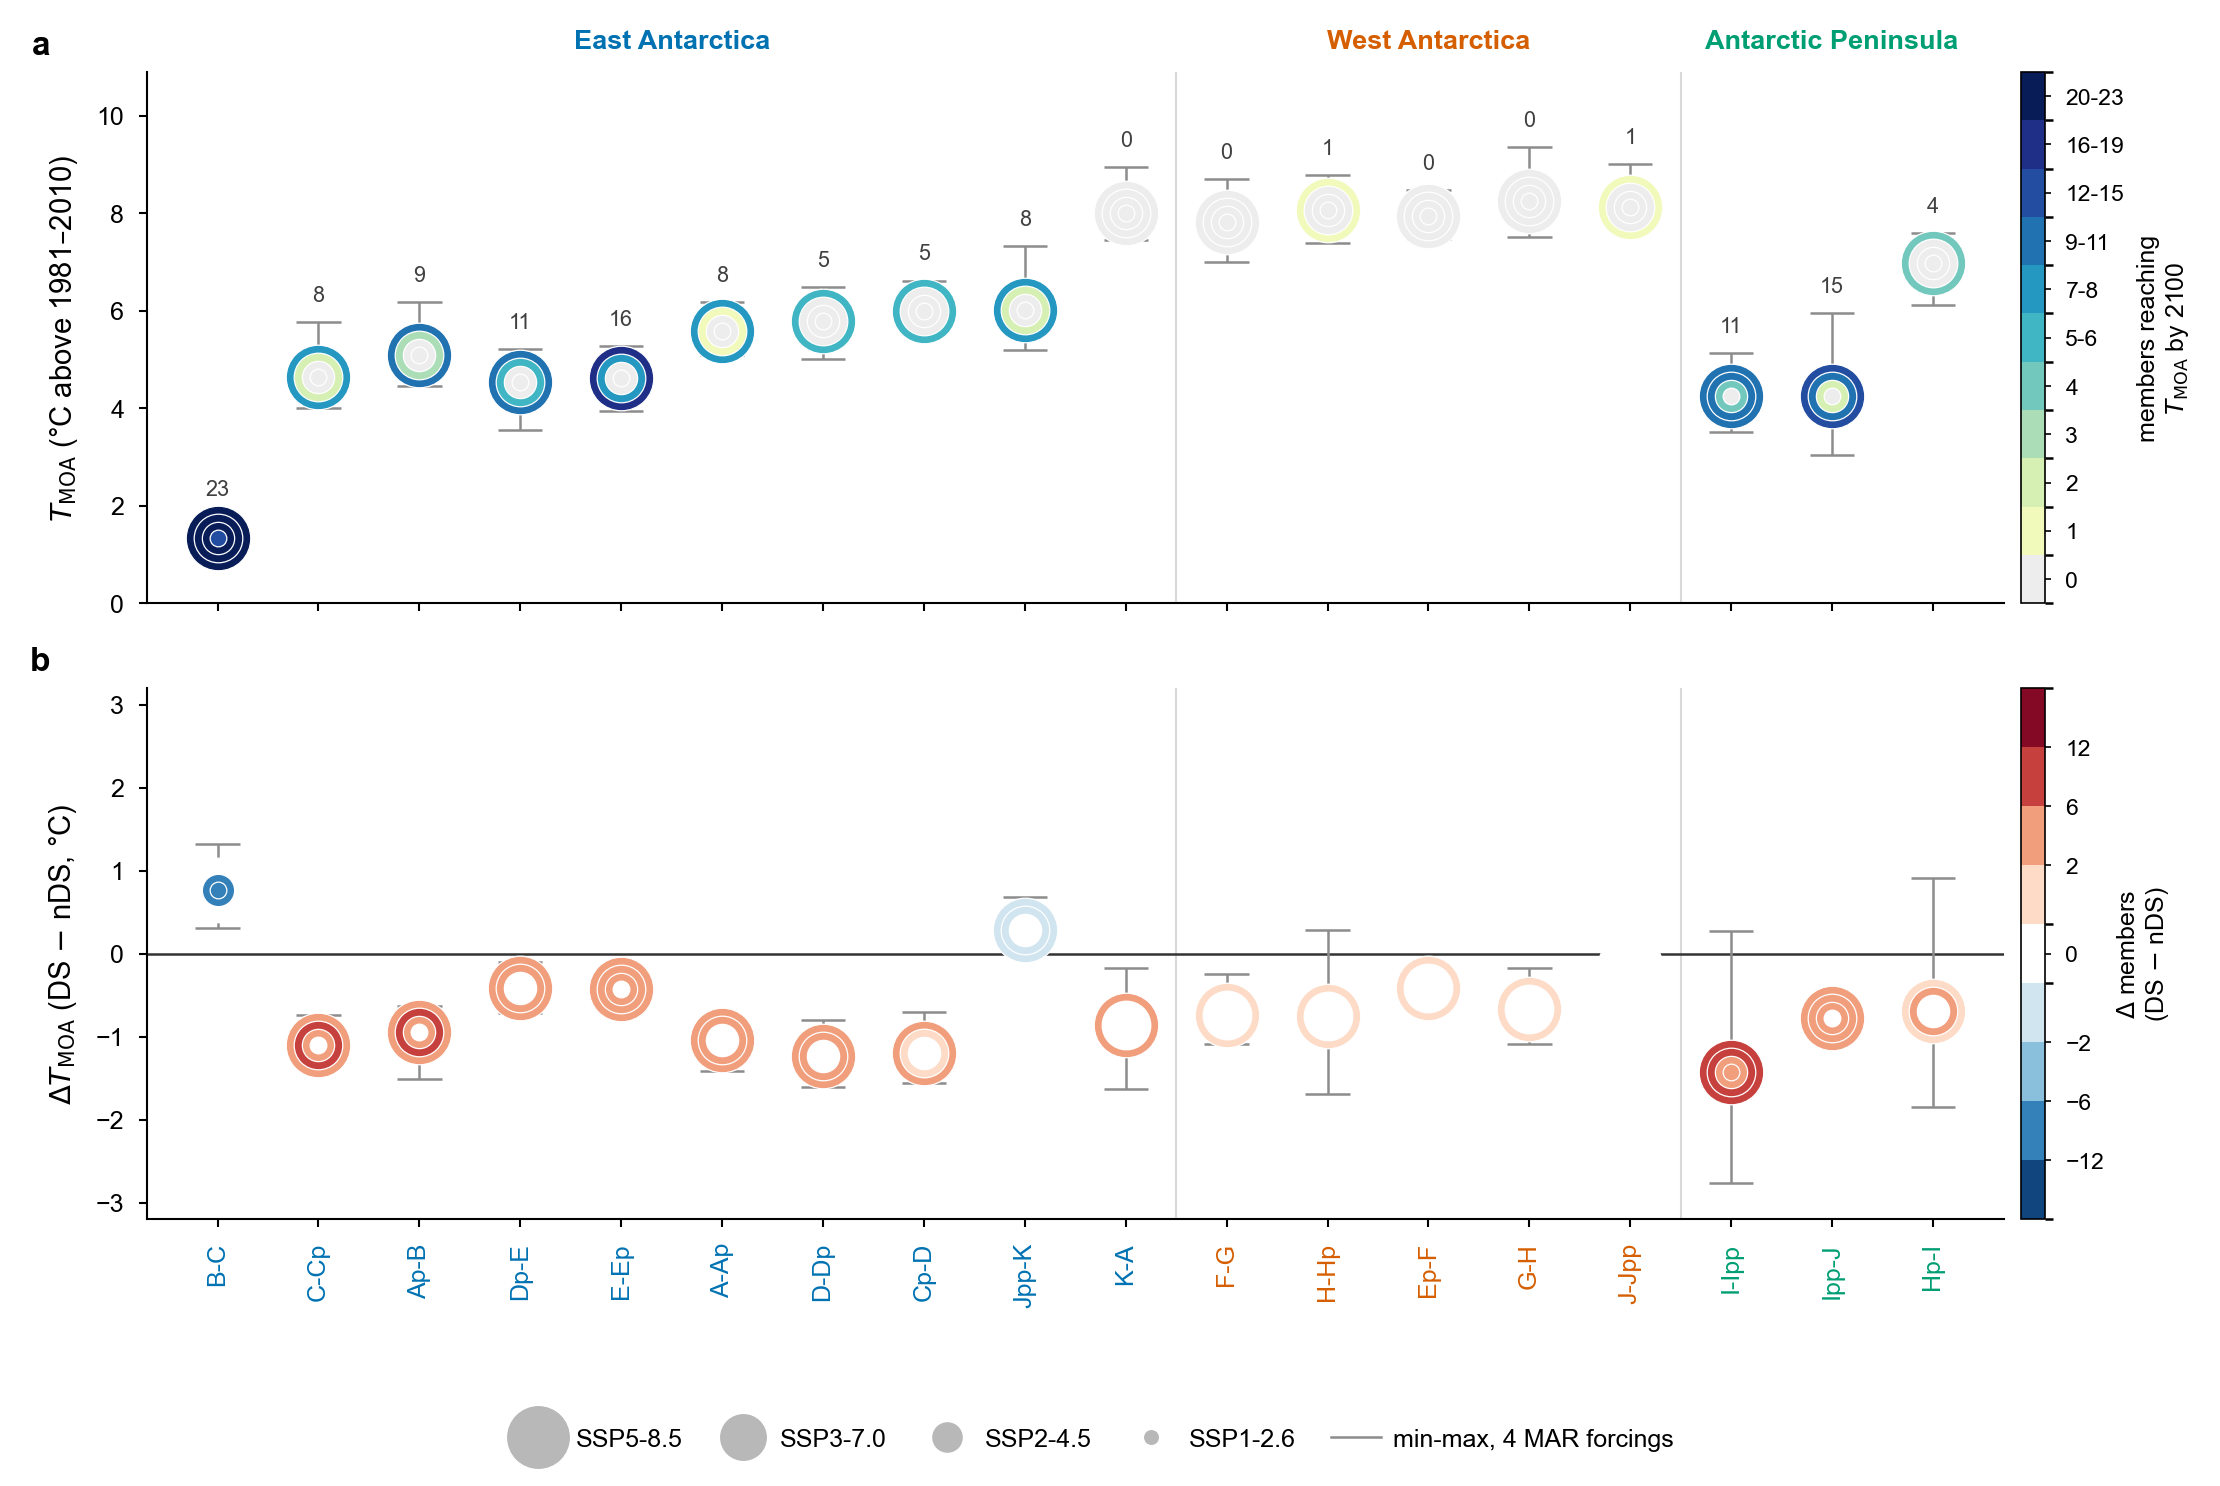

In [9]:
PANELS      = ["nDS", "diff"]
FIG_W_MM, PANEL_H_MM = 183.0, 52.0
SORT_WITHIN = "DS"
SCEN_SIZE   = {"ssp585": 240.0, "ssp370": 136.0, "ssp245": 60.0, "ssp126": 16.0}
ANNOT_OUTER, FS_ANNOT = True, 5.2

CNT_BINS = [0, 1, 2, 3, 4, 5, 7, 9, 12, 16, 20, 24]
CNT_LABS = ["0", "1", "2", "3", "4", "5-6", "7-8",
            "9-11", "12-15", "16-19", "20-23"]
CNT_CM = ListedColormap([(0.93, 0.93, 0.93)] +
                        [plt.get_cmap("YlGnBu")(v) for v in
                         np.linspace(0.10, 1.0, len(CNT_LABS) - 1)])
CNT_NORM = BoundaryNorm(CNT_BINS, CNT_CM.N)

DIF_BINS = [-24, -12, -6, -2, -0.5, 0.5, 2, 6, 12, 24]
DIF_CM = ListedColormap([plt.get_cmap("RdBu_r")(v) for v in
                         (0.04, 0.16, 0.29, 0.40)] + [(1, 1, 1)] +
                        [plt.get_cmap("RdBu_r")(v) for v in
                         (0.60, 0.71, 0.84, 0.96)])
DIF_NORM = BoundaryNorm(DIF_BINS, DIF_CM.N)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7, "axes.labelsize": 7, "axes.titlesize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "axes.linewidth": 0.5, "xtick.major.width": 0.5, "ytick.major.width": 0.5,
    "xtick.major.size": 2.0, "ytick.major.size": 2.0,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
    "savefig.bbox": "tight",
})


def panel_order():
    ref = TH[SORT_WITHIN]
    return [b for s in SECT_ORDER
            for b in sorted([x for x in ALL_18 if SECTOR[x] == s
                             and np.isfinite(ref[x]["mean"])],
                            key=lambda x: ref[x]["mean"])]


def panel_data(kind):
    kk = CNT.set_index(["run", "basin", "scen"])["k"]
    d = {}
    for b in ALL_18:
        if kind == "diff":
            t0, t1 = TH["DS"][b]["mean"], TH["nDS"][b]["mean"]
            pm0, pm1 = TH["DS"][b]["pm"], TH["nDS"][b]["pm"]
            pmd = [pm0[m] - pm1[m] for m in M_ORDER
                   if np.isfinite(pm0.get(m, np.nan))
                   and np.isfinite(pm1.get(m, np.nan))]
            d[b] = dict(y=t0 - t1, lo=min(pmd) if pmd else np.nan,
                        hi=max(pmd) if pmd else np.nan,
                        c={s: int(kk[("DS", b, s)]) - int(kk[("nDS", b, s)])
                           for s in SCEN4})
        else:
            d[b] = dict(y=TH[kind][b]["mean"], lo=TH[kind][b]["lo"],
                        hi=TH[kind][b]["hi"],
                        c={s: int(kk[(kind, b, s)]) for s in SCEN4})
    return d


def make_figure():
    order = panel_order()
    data = {k: panel_data(k) for k in PANELS}
    figw = FIG_W_MM / 25.4
    figh = (len(PANELS) * PANEL_H_MM + 23.0) / 25.4
    fig = plt.figure(figsize=(figw, figh), dpi=300)
    gs = fig.add_gridspec(len(PANELS), 2, width_ratios=[1, 0.013],
                          left=0.062, right=0.94, top=0.935, bottom=0.170,
                          hspace=0.16, wspace=0.018)
    axes = []
    for idx, kind in enumerate(PANELS):
        ax = fig.add_subplot(gs[idx, 0], sharex=axes[0] if axes else None)
        axes.append(ax)
        cm, nm = ((DIF_CM, DIF_NORM) if kind == "diff" else (CNT_CM, CNT_NORM))
        dat = data[kind]
        ax.set_axisbelow(True)
        if kind == "diff":
            ax.axhline(0, color="0.2", lw=0.6, zorder=2)

        for i, b in enumerate(order):
            r = dat[b]
            if np.isfinite(r["lo"]) and np.isfinite(r["hi"]) and r["hi"] > r["lo"]:
                ax.vlines(i, r["lo"], r["hi"], color="0.55", lw=0.6, zorder=3)
                ax.hlines([r["lo"], r["hi"]], i - 0.22, i + 0.22,
                          color="0.55", lw=0.6, zorder=3)
            for z, s in enumerate(SCEN4):
                ax.scatter(i, r["y"], s=SCEN_SIZE[s], c=[cm(nm(r["c"][s]))],
                           edgecolor="white", linewidth=0.3, zorder=5 + z)
            if ANNOT_OUTER and kind != "diff":
                ax.annotate(f"{r['c'][SCEN4[0]]:d}",
                            (i, np.nanmax([r["y"], r["hi"]])),
                            textcoords="offset points", xytext=(0, 4.0),
                            ha="center", va="bottom", fontsize=FS_ANNOT,
                            color="0.25", zorder=9)

        bounds, k = [], 0
        for s in SECT_ORDER:
            n = sum(1 for b in order if SECTOR[b] == s)
            if n:
                bounds.append((s, k, k + n - 1)); k += n
        for _s, _i0, i1 in bounds[:-1]:
            ax.axvline(i1 + 0.5, color="0.85", lw=0.5, zorder=1)
        if idx == 0:
            for s, i0, i1 in bounds:
                ax.text((i0 + i1) / 2, 1.035, SECT_FULL[s],
                        transform=ax.get_xaxis_transform(), ha="center",
                        va="bottom", fontsize=6.5, color=SECT_COL[s],
                        fontweight="bold")

        ax.set_xlim(-0.7, len(order) - 0.3)
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order, rotation=90, ha="center", va="top")
        for lab in ax.get_xticklabels():
            lab.set_color(SECT_COL[SECTOR[lab.get_text()]])
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
        ax.text(-0.052, 1.02, "abc"[idx], transform=ax.transAxes,
                fontsize=8, fontweight="bold", ha="right", va="bottom")

        cax = fig.add_subplot(gs[idx, 1])
        cb = fig.colorbar(plt.cm.ScalarMappable(norm=nm, cmap=cm), cax=cax)
        cb.outline.set_linewidth(0.4)
        cb.ax.tick_params(labelsize=5.5, length=1.5, width=0.4)
        if kind == "diff":
            cb.set_ticks([-12, -6, -2, 0, 2, 6, 12])
            cb.set_label("$\\Delta$ members\n(DS $-$ nDS)", fontsize=6, labelpad=3)
            ax.set_ylabel("$\\Delta T_\\mathrm{MOA}$ (DS $-$ nDS, °C)")
            m = np.nanmax(np.abs([v for b in order for v in
                                  (dat[b]["lo"], dat[b]["hi"], dat[b]["y"])]))
            ax.set_ylim(-np.ceil(m * 2) / 2 - 0.2, np.ceil(m * 2) / 2 + 0.2)
        else:
            cb.set_ticks([(CNT_BINS[j] + CNT_BINS[j + 1]) / 2
                          for j in range(len(CNT_LABS))])
            cb.ax.set_yticklabels(CNT_LABS)
            cb.set_label("members reaching\n$T_\\mathrm{MOA}$ by 2100",
                         fontsize=6, labelpad=3)
            ax.set_ylabel("$T_\\mathrm{MOA}$ (°C above 1981–2010)")
            ax.set_ylim(0, np.ceil(max(dat[b]["hi"] if np.isfinite(dat[b]["hi"])
                                       else dat[b]["y"] for b in order))
                        + (0.9 if ANNOT_OUTER else 0.5))
        if idx < len(PANELS) - 1:
            plt.setp(ax.get_xticklabels(), visible=False)

    h = [Line2D([], [], marker="o", ls="none", markerfacecolor="0.72",
                markeredgecolor="white", markeredgewidth=0.4,
                markersize=np.sqrt(SCEN_SIZE[s]), label=SCEN_LAB[s])
         for s in SCEN4]
    h.append(Line2D([], [], color="0.55", lw=0.6,
                    label="min-max, 4 MAR forcings"))
    fig.legend(handles=h, loc="lower center", bbox_to_anchor=(0.5, 0.004),
               ncol=5, frameon=False, handletextpad=0.5, columnspacing=1.4,
               borderpad=0.2)

    fig.savefig(f"{FIG_DIR}/fig_tmoa_pub.pdf")
    fig.savefig(f"{FIG_DIR}/fig_tmoa_pub.png", dpi=600)
    return fig


FIG = make_figure()
print("written:", f"{FIG_DIR}/fig_tmoa_pub.pdf")

### $T_\mathrm{CROSS}$ against $T_\mathrm{MOA}$ figure

fixed thresholds per basin (identical wherever shown):
  basin     T_MOA  T_MOA_nDS  T_CROSS
  A-Ap       4.55       5.59     4.17
  Ap-B       4.14       5.09     2.52
  B-C        2.12       1.35     1.82
  C-Cp       3.55       4.65     3.27
  Cp-D       4.80       6.00     2.98
  D-Dp       4.57       5.80     4.77
  Dp-E       4.14       4.55     0.55
  E-Ep       4.21       4.63     4.18
  Ep-F       7.53       7.94     2.79
  F-G        7.10       7.83     4.66
  G-H        7.58       8.25     4.57
  H-Hp       7.32       8.07     4.59
  Hp-I       6.29       6.98     4.07
  I-Ipp      2.84       4.26     1.81
  Ipp-J      3.49       4.26     3.73
  J-Jpp      7.99       8.13      nan
  Jpp-K      6.31       6.02     4.67
  K-A        7.14       8.00     5.26


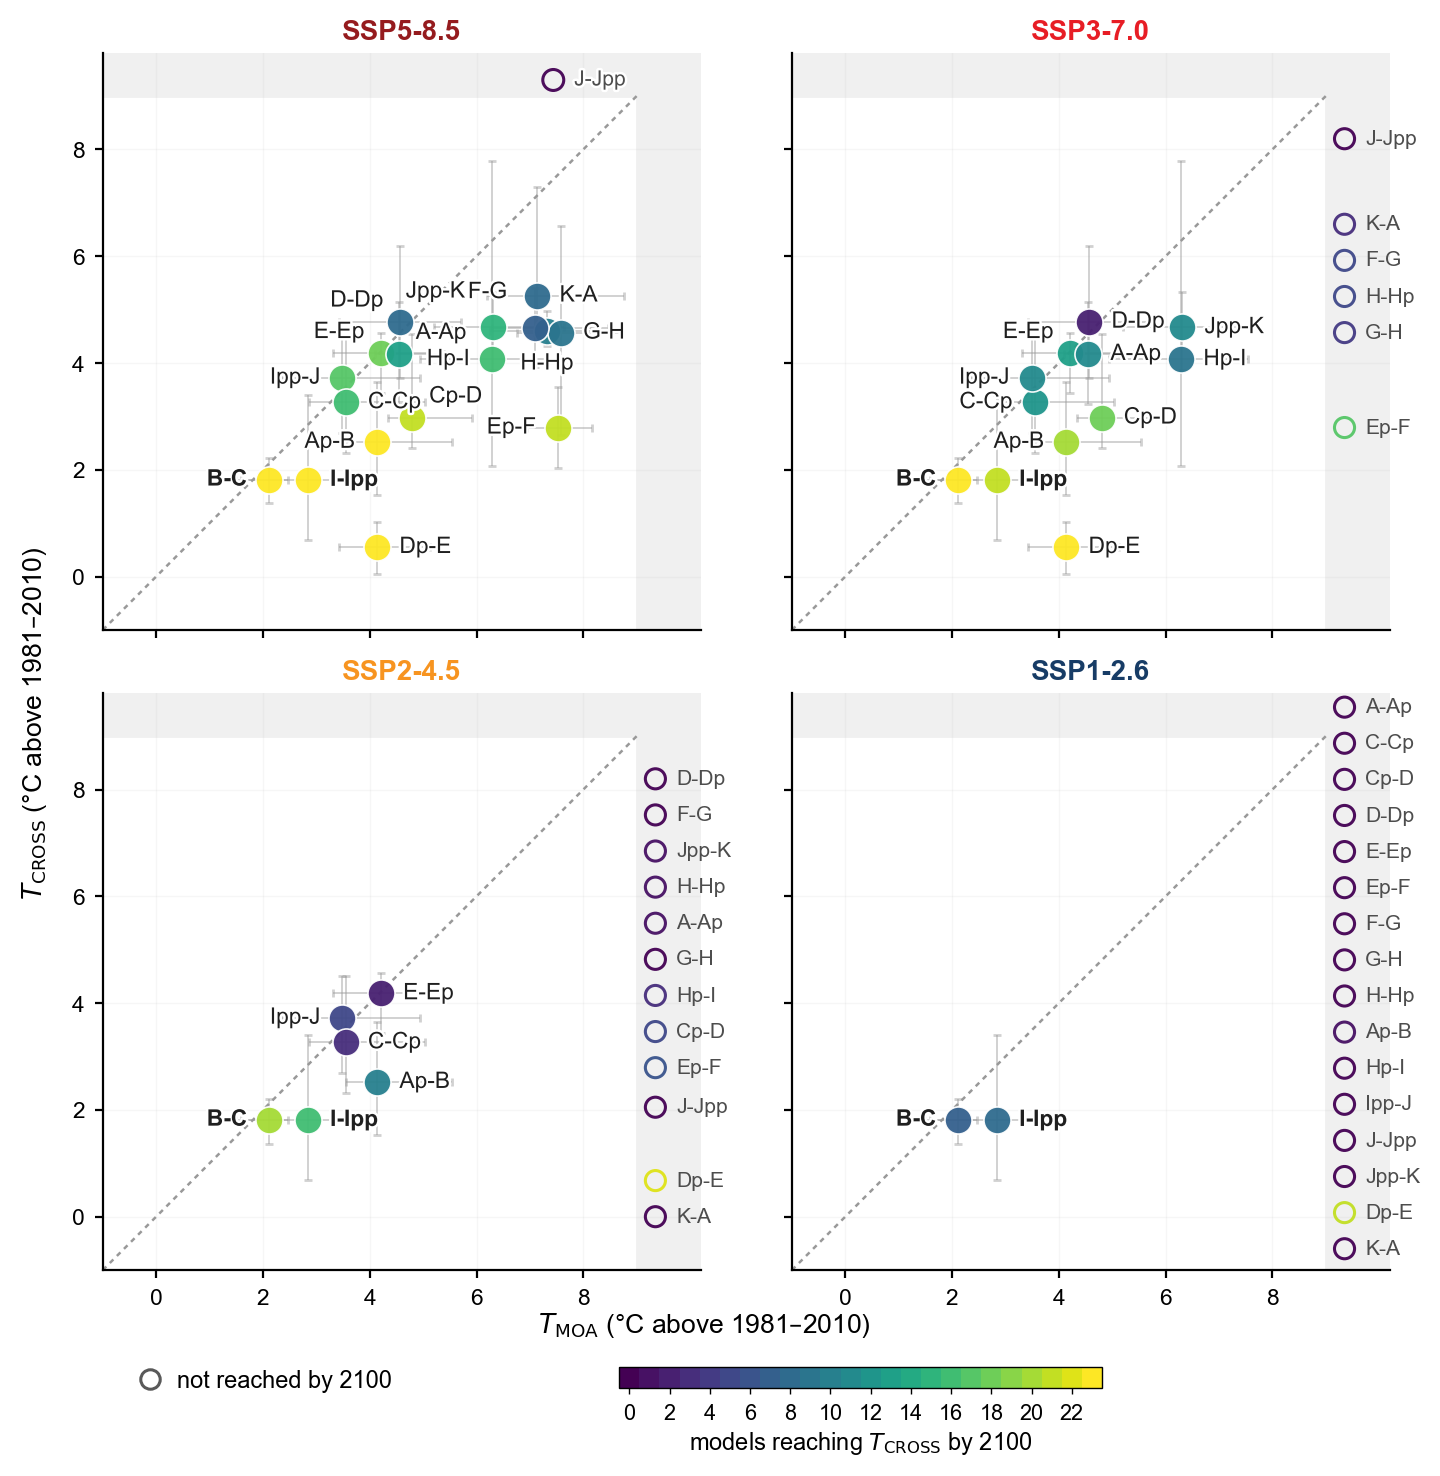

In [ ]:
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
})

PMX_SMOOTH     = globals().get("PMX_SMOOTH", 10)
PMX_TREND_WIN  = globals().get("PMX_TREND_WIN", 30)
PMX_MAX_EXTRAP = globals().get("PMX_MAX_EXTRAP", 200)

if "smooth_ts" not in globals():
    def smooth_ts(ts, n=PMX_SMOOTH):
        return pd.Series(ts).rolling(n, center=True,
                                     min_periods=n // 2).mean().values

if "_pmx_smooth" not in globals():
    def _pmx_smooth(ts):
        return smooth_ts(ts, PMX_SMOOTH)

if "pmx_first_cross" not in globals():
    def pmx_first_cross(yrs, ano, thr):
        yrs = np.asarray(yrs); s = _pmx_smooth(ano)
        idx = np.where((yrs >= 2015) & np.isfinite(s) & (s >= thr))[0]
        if len(idx):
            return float(yrs[idx[0]]), False
        a = np.asarray(ano, dtype=float); ok = np.isfinite(a)
        if ok.sum() < 5:
            return np.nan, False
        ty = yrs[ok][-PMX_TREND_WIN:]; tv = a[ok][-PMX_TREND_WIN:]
        sl, ic = np.polyfit(ty, tv, 1)
        if sl <= 0:
            return np.nan, False
        yc = (thr - ic) / sl
        last = int(yrs[ok][-1])
        return (float(yc), True) if last < yc <= last + PMX_MAX_EXTRAP \
               else (np.nan, False)

if "ALL_18" not in globals():
    ALL_18 = ["A-Ap", "Ap-B", "B-C", "C-Cp", "Cp-D", "D-Dp", "Dp-E", "E-Ep",
              "Ep-F", "F-G", "G-H", "H-Hp", "Hp-I", "I-Ipp", "Ipp-J", "J-Jpp",
              "Jpp-K", "K-A"]

if "basin_tas" not in globals():
    raise NameError(
        "basin_tas is not in this kernel then it is the only input this cell "
        "cannot rebuild. Run the TAS PROXY cell, then the EXTEND-to-18 cell, "
        "then the SSP2-4.5 drop-in.")

_gap = [(b, sk) for b in ALL_18
        for sk in ["ssp585", "ssp370", "ssp245", "ssp126"]
        if len(basin_tas.get(b, {}).get(sk, {}) or {}) == 0]
if _gap:
    raise RuntimeError(
        f"basin_tas is incomplete  {len(_gap)} empty basin-scenario slots: "
        f"{sorted({b for b, _ in _gap})}. Run the FIX-BT repair cell; "
        " ")

SCEN_KEYS = ["ssp585", "ssp370", "ssp245", "ssp126"]
SCEN_LAB  = {"ssp126": "SSP1-2.6", "ssp245": "SSP2-4.5",
             "ssp370": "SSP3-7.0", "ssp585": "SSP5-8.5"}
SCEN_TCOL = {"ssp126": "#173C66", "ssp245": "#F79420",
             "ssp370": "#E71D25", "ssp585": "#951B1E"}
LO, HI    = -1.0, 9.0
HI_YEAR   = 2100
GUT_X, GUT_Y = 10.2, 9.8
CLX, CLY  = 9.35, 9.30
KEY_BASINS = ["B-C", "I-Ipp"]
FS_IN, FS_CL = 8.2, 7.6       
M_ORDER = ["CNRM", "IPSL", "MPI", "UKM"]
M_LONG  = {"CNRM": "CNRM-CM6-1", "IPSL": "IPSL-CM6A-LR",
           "MPI": "MPI-ESM1-2-HR", "UKM": "UKESM1-0-LL"}

MARK_S    = 95.0       
_COL_CMAP = "viridis"   
_CROSS_DEF = "sustained"    #or first
_SUSTAIN_N = 20           
_QUAL   = "ens_median"      #or common_set or ensemble_mean
_K_FRAC   = 0.5
_MINORITY = "fill"          #fill, show, hide
_QUAL_ENS = "all"           
_TMOA_CSV = "/Users/dashakan/Desktop/scripts_AIS/tables/TMOA_table_350_700m.csv"
_TM = pd.read_csv(_TMOA_CSV)
_TM["basin"] = _TM["basin"].str.strip();  _TM = _TM.set_index("basin")
_TC = pd.read_csv("/Users/dashakan/Desktop/scripts_AIS/tables/T_CROSS_table_350_700m_polyfit.csv").rename(columns={"Basin": "basin"})
_TC["basin"] = _TC["basin"].str.strip();  _TC = _TC.set_index("basin")
# nDS thresholds: not used by this figure, but can be printed out
_NDS_CSV = "/Users/dashakan/Desktop/scripts_AIS/tables/TMOA_table_nDS_350_700m.csv"
if os.path.exists(_NDS_CSV):
    _TMN = pd.read_csv(_NDS_CSV)
    _TMN["basin"] = _TMN["basin"].astype(str).str.strip()
    _TMN = _TMN.set_index("basin")
else:
    _TMN = None

def _thr(tbl, b, s):
    if b not in tbl.index: return np.nan
    v = tbl.loc[b, s]
    return float(v) if pd.notna(v) else np.nan

#basin thresholds
def _tmB(b):                      
    if b not in _TM.index: return np.nan
    v = _TM.loc[b, "mean"]
    return float(v) if pd.notna(v) else np.nan

def _tcB(b):                      
    if b not in _TC.index: return np.nan
    v = pd.to_numeric(_TC.loc[b, M_ORDER], errors="coerce").mean()
    return float(v) if pd.notna(v) else np.nan

def _tmB_nds(b):                   
    if _TMN is None or b not in _TMN.index: return np.nan
    v = _TMN.loc[b, "mean"]
    return float(v) if pd.notna(v) else np.nan

print("thresholds per basin:")
if _TMN is None:
    print(f"  {'basin':7s} {'T_MOA':>7s} {'T_CROSS':>8s}")
    for b in ALL_18:
        print(f"  {b:7s} {_tmB(b):7.2f} {_tcB(b):8.2f}")
else:
    print(f"  {'basin':7s} {'T_MOA':>7s} {'T_MOA_nDS':>10s} {'T_CROSS':>8s}")
    for b in ALL_18:
        print(f"  {b:7s} {_tmB(b):7.2f} {_tmB_nds(b):10.2f} {_tcB(b):8.2f}")

def _ens_items(b, sk):
    """[(model, series)] over the ensemble selected by _QUAL_ENS."""
    _d = basin_tas.get(b, {}).get(sk, {})
    if _QUAL_ENS == "focus":
        return [(s, _d.get(M_LONG[s])) for s in M_ORDER
                if _d.get(M_LONG[s]) is not None]
    return [(_m, _ts) for _m, _ts in _d.items() if _ts is not None]

def _fc(_yy, _aa, _thr):
    """reach year under _CROSS_DEF (mirrors the timing cell)."""
    if _CROSS_DEF == "first":
        return pmx_first_cross(_yy, _aa, _thr)
    _yv = np.asarray(_yy); _sv = _pmx_smooth(_aa)
    _okv = np.isfinite(_sv)
    _fin = np.where(_okv)[0]
    _last = _fin[-1] if len(_fin) else -1
    for _i in np.where((_yv >= 2015) & _okv & (_sv >= _thr))[0]:
        _j = _i
        while _j + 1 < len(_sv) and np.isfinite(_sv[_j + 1]) \
                and _sv[_j + 1] >= _thr:
            _j += 1
        if (_j - _i + 1) >= _SUSTAIN_N or _j == _last:
            return float(_yv[_i]), False
    _v0, _e0 = pmx_first_cross(_yy, _aa, _thr)
    if _e0:
        return _v0, _e0
    return np.nan, False

_ORDER_WEAK = ["ssp126", "ssp245", "ssp370", "ssp585"] 

def _cross_map_q(b, thr):
    out = {}
    for sk in SCEN_KEYS:
        d = {}
        if np.isfinite(thr):
            for s in M_ORDER:
                ts = basin_tas.get(b, {}).get(sk, {}).get(M_LONG[s])
                if ts is None:
                    continue
                v, e = _fc(ts[0], ts[1], thr)
                if np.isfinite(v) and (not e) and v <= HI_YEAR:
                    d[s] = float(v)
        out[sk] = d
    return out

_CSQ = {}
for _b in ALL_18:
    for _ax, _thr0 in (("x", _tmB(_b)), ("y", _tcB(_b))):
        _cm = _cross_map_q(_b, _thr0)
        _ref = set()
        for _sk in _ORDER_WEAK:
            if _cm[_sk]:
                _ref = set(_cm[_sk]); break
        _CSQ[(_b, _ax)] = (_cm, _ref)

def _cs_ok(b, sk, ax):
    _cm, _ref = _CSQ[(b, ax)]
    if not _ref or not _ref.issubset(_cm[sk]):
        return np.nan
    return float(np.mean([_cm[sk][m] for m in _ref]))

def _qual_series(b, sk):
    """Multi-model mean anomaly series (mirrors the timing cell)."""
    d = basin_tas.get(b, {}).get(sk, {})
    items = [d.get(M_LONG[s]) for s in M_ORDER] if _QUAL_ENS == "focus" \
            else list(d.values())
    items = [ts for ts in items if ts is not None]
    if not items:
        return None
    _st = [pd.Series(np.asarray(ts[1], float), index=np.asarray(ts[0]))
           for ts in items]
    _mm = pd.concat(_st, axis=1).mean(axis=1, skipna=True).sort_index()
    return (_mm.index.values, _mm.values)

_agg = []
for b in ALL_18:
    tmb, tcb = _tmB(b), _tcB(b)
    xw = [t for s in M_ORDER if np.isfinite(t := _thr(_TM, b, s))]
    yw = [t for s in M_ORDER if np.isfinite(t := _thr(_TC, b, s))]
    for sk in SCEN_KEYS:
        kx = ky = 0                       #ensemble members reaching by 2100
        for _nm, ts in _ens_items(b, sk):
            if np.isfinite(tmb):
                ym, em = _fc(ts[0], ts[1], tmb)
                if np.isfinite(ym) and (not em) and ym <= HI_YEAR:
                    kx += 1
            if np.isfinite(tcb):
                yc, ec = _fc(ts[0], ts[1], tcb)
                if np.isfinite(yc) and (not ec) and yc <= HI_YEAR:
                    ky += 1
        nt = int(ky)                      #T_CROSS count  circle COLOUR
        navail = len(_ens_items(b, sk))   # ensemble size (for reference)
        _minx = _miny = False
        if _QUAL == "ens_median":
            _mav = navail
            _kq = int(np.ceil(_K_FRAC * _mav)) if _mav else 1
            if _MINORITY in ("show", "fill"):    #keep the basin visible
                _minx = 1 <= kx < _kq
                _miny = 1 <= ky < _kq
                kx = int(kx >= 1)
                ky = int(ky >= 1)
            else:
                kx = int(kx >= _kq)
                ky = int(ky >= _kq)
        elif _QUAL == "common_set":
            kx = int(np.isfinite(_cs_ok(b, sk, "x")))
            ky = int(np.isfinite(_cs_ok(b, sk, "y")))
        elif _QUAL == "ensemble_mean":
            _ts_m = _qual_series(b, sk)
            kx = ky = 0
            if _ts_m is not None:
                if np.isfinite(tmb):
                    _v, _e = _fc(_ts_m[0], _ts_m[1], tmb)
                    kx = int(np.isfinite(_v) and (not _e) and _v <= HI_YEAR)
                if np.isfinite(tcb):
                    _v, _e = _fc(_ts_m[0], _ts_m[1], tcb)
                    ky = int(np.isfinite(_v) and (not _e) and _v <= HI_YEAR)
        _agg.append({"basin": b, "scen": sk,
                     "nt": nt, "navail": navail,
                     "minx": _minx, "miny": _miny,
                     "x": tmb, "cx": (kx == 0) or not np.isfinite(tmb),
                     "kx": kx,
                     "xlo": np.min(xw) if xw else np.nan,
                     "xhi": np.max(xw) if xw else np.nan,
                     "y": tcb, "cy_": (ky == 0) or not np.isfinite(tcb),
                     "ky": ky,
                     "ylo": np.min(yw) if yw else np.nan,
                     "yhi": np.max(yw) if yw else np.nan})
ag = pd.DataFrame(_agg)

#colour scale = model count reaching T_CROSS
_counts = ag["nt"].to_numpy()
_Nmax = int(max(1, np.nanmax(_counts)))
_CM = plt.get_cmap(_COL_CMAP)
_cnorm = mpl.colors.BoundaryNorm(np.arange(-0.5, _Nmax + 1.5, 1.0), _CM.N)
def _col(n):
    n = 0 if (n is None or not np.isfinite(n)) else int(n)
    return _CM(_cnorm(n))

_MDIAM = 2.0 * np.sqrt(MARK_S / np.pi)   #marker diameter (points)

def _dodge1d(vals, gap, lo, hi):
    idx = np.argsort(vals)
    out = np.array(vals, float)
    for j in range(1, len(idx)):
        a, b = idx[j - 1], idx[j]
        if out[b] - out[a] < gap:
            out[b] = out[a] + gap
    shift = max(0, out[idx[-1]] - hi) if len(idx) else 0
    out[idx] -= shift
    if len(idx) and out[idx[0]] < lo:
        out[idx] += lo - out[idx[0]]
    return out

#fig

FS_TITLE, FS_TICK, FS_AX = 10.0, 8.2, 9.5      #panel title,ticks,axis titles
FS_LEG, FS_CBL, FS_CBT   = 8.5, 8.5, 7.8       #legend,colourbar label,colourbar ticks
FIGW, FIGH = 7.1, 7.2                          
WSP, HSP   = 0.14, 0.11                        #gaps between columns,rows
MARG = dict(left=0.074, right=0.985, bottom=0.12, top=0.965)

fig, axes = plt.subplots(2, 2, figsize=(FIGW, FIGH), dpi=200,
                         sharex=True, sharey=True,
                         gridspec_kw={"wspace": WSP, "hspace": HSP})
fig.subplots_adjust(**MARG)
axf = axes.flatten()                           #row:[SSP5-8.5, SSP3-7.0, SSP2-4.5, SSP1-2.6]


for ax in axf:
    ax.set_xlim(LO, GUT_X); ax.set_ylim(LO, GUT_Y); ax.set_aspect("equal")
fig.canvas.draw()
_bb = axf[0].get_window_extent()
PT_X = (GUT_X - LO) / (_bb.width  * 72 / fig.dpi)
PT_Y = (GUT_Y - LO) / (_bb.height * 72 / fig.dpi)
HALO = [pe.withStroke(linewidth=1.8, foreground="white")]

DIRS = [(1.0, 0.0, "left"), (-1.0, 0.0, "right"),
        (0.75, 0.95, "left"), (-0.75, 0.95, "right"),
        (0.75, -1.05, "left"), (-0.75, -1.05, "right"),
        (0.0, 1.25, "center"), (0.0, -1.45, "center")]

def _place_labels(ax, items, seed_boxes):
    boxes = list(seed_boxes)
    #order labels by T_CROSS count
    for x, y, prio, txt, bold in sorted(items, key=lambda t: -t[2]):
        r = np.sqrt(MARK_S / np.pi)
        w = 0.58 * FS_IN * len(txt) * PT_X
        h = 1.15 * FS_IN * PT_Y
        best, best_pen = None, None
        for pad in (2.5, 8.0):
            for ux, uy, ha in DIRS:
                lx = x + (r + pad) * ux * PT_X
                ly = y + (r + pad) * uy * PT_Y
                if ha == "left":    x0, x1 = lx, lx + w
                elif ha == "right": x0, x1 = lx - w, lx
                else:               x0, x1 = lx - w / 2, lx + w / 2
                y0, y1 = ly - h / 2, ly + h / 2
                if x0 < LO + 0.1 or x1 > HI - 0.1 or y0 < LO + 0.1 or y1 > HI - 0.1:
                    continue
                n = sum(1 for b in boxes
                        if x0 < b[1] and x1 > b[0] and y0 < b[3] and y1 > b[2])
                pen = n * 100 + pad
                if best_pen is None or pen < best_pen:
                    best, best_pen = (lx, ly, ha, x0, x1, y0, y1), pen
                if pen == pad:
                    break
            if best_pen is not None and best_pen < 100:
                break
        if best is None:
            best = (x + (r + 2.5) * PT_X, y, "left",
                    x + (r + 2.5) * PT_X, x + (r + 2.5) * PT_X + w,
                    y - h / 2, y + h / 2)
        lx, ly, ha, x0, x1, y0, y1 = best
        ax.annotate(txt, xy=(x, y), xytext=(lx, ly), fontsize=FS_IN,
                    fontweight="bold" if bold else "normal",
                    color="0.12", ha=ha, va="center", zorder=8,
                    path_effects=HALO)
        boxes.append((x0, x1, y0, y1))

for ax, sk in zip(axf, SCEN_KEYS):
    ax.set_axisbelow(True)
    ax.grid(alpha=0.10, lw=0.5)
    ax.axvspan(HI, GUT_X, color="0.94", zorder=0)
    ax.axhspan(HI, GUT_Y, color="0.94", zorder=0)
    dlim = min(HI, GUT_Y)
    ax.plot([LO, dlim], [LO, dlim], color="0.6", lw=0.9, ls=(0, (2, 2)), zorder=1)

    sub = ag[ag.scen == sk].copy()
    inr = sub[~(sub.cx | sub.cy_)].sort_values("nt", ascending=False)
    ycl = sub[sub.cy_ & ~sub.cx].copy()
    xcl = sub[sub.cx].copy()

    seed = []
    for _, r in inr.iterrows():
        c = _col(r.nt)
        if np.isfinite(r.xlo) and r.xhi > r.xlo:
            ax.errorbar(r.x, r.y, xerr=[[r.x - r.xlo], [r.xhi - r.x]],
                        fmt="none", ecolor="0.60", elinewidth=0.7,
                        capsize=1.6, alpha=0.45, zorder=3)
        if np.isfinite(r.ylo) and r.yhi > r.ylo:
            ax.errorbar(r.x, r.y, yerr=[[r.y - r.ylo], [r.yhi - r.y]],
                        fmt="none", ecolor="0.60", elinewidth=0.7,
                        capsize=1.6, alpha=0.45, zorder=3)
        ax.scatter(r.x, r.y, s=MARK_S, c=[c], edgecolor="white",
                   linewidth=0.6, alpha=0.95, zorder=5)
        rr = np.sqrt(MARK_S / np.pi)
        seed.append((r.x - rr * PT_X, r.x + rr * PT_X,
                     r.y - rr * PT_Y, r.y + rr * PT_Y))

    if len(ycl):
        _w = max((0.58 * FS_CL * ycl.basin.str.len().max() + 8) * PT_X,
                 (_MDIAM + 2) * PT_X)
        ycl["xx"] = _dodge1d(ycl.x.values, gap=_w, lo=LO + 0.4, hi=HI - _w)
        for _, r in ycl.iterrows():
            c = _col(r.nt)
            rr = np.sqrt(MARK_S / np.pi)
            ax.scatter(r.xx, CLY, s=MARK_S * 0.6, facecolors="none",
                       edgecolors=[c], linewidth=1.1, alpha=0.95, zorder=4)
            ax.annotate(r.basin, xy=(r.xx + (rr + 2) * PT_X, CLY),
                        fontsize=FS_CL, color="0.3", ha="left", va="center",
                        zorder=7, path_effects=HALO,
                        fontweight="bold" if r.basin in KEY_BASINS else "normal")

    if len(xcl):
        yv = np.where(np.isfinite(xcl.y) & ~xcl.cy_, xcl.y, np.nan)
        n_no = int(np.isnan(yv).sum())
        slots = iter(np.linspace(HI - 0.8, LO + 1.0, max(n_no, 1)))
        yv = np.array([v if np.isfinite(v) else next(slots) for v in yv])
        xcl["yy"] = _dodge1d(yv, gap=(_MDIAM + 2) * PT_Y, lo=LO + 0.4, hi=HI - 0.3)
        for _, r in xcl.iterrows():
            c = _col(r.nt)
            rr = np.sqrt(MARK_S / np.pi)
            ax.scatter(CLX, r.yy, s=MARK_S * 0.55, facecolors="none",
                       edgecolors=[c], linewidth=1.1, alpha=0.95, zorder=4)
            ax.annotate(r.basin, xy=(CLX + (rr + 2) * PT_X, r.yy),
                        fontsize=FS_CL, color="0.3", ha="left", va="center",
                        zorder=7,
                        fontweight="bold" if r.basin in KEY_BASINS else "normal")

    _place_labels(ax,
                  [(r.x, r.y, r.nt, r.basin, r.basin in KEY_BASINS)
                   for _, r in inr.iterrows()],
                  seed)

    ax.set_title(SCEN_LAB[sk], fontsize=FS_TITLE, color=SCEN_TCOL[sk],
                 fontweight="bold", pad=5)
    tk = [0, 2, 4, 6, 8]
    ax.set_xticks(tk); ax.set_xticklabels(map(str, tk), fontsize=FS_TICK)
    ax.set_yticks(tk); ax.set_yticklabels(map(str, tk), fontsize=FS_TICK)
    ax.set_xlim(LO, GUT_X); ax.set_ylim(LO, GUT_Y)
    ax.set_aspect("equal")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_linewidth(0.8)
    ax.tick_params(length=3, width=0.8)

# shared axis titles 
fig.supylabel(r"$T_{\mathrm{CROSS}}$ (°C above 1981–2010)", fontsize=FS_AX, x=0.018)
fig.supxlabel(r"$T_{\mathrm{MOA}}$ (°C above 1981–2010)",  fontsize=FS_AX, y=0.072)

# legend
h_o = [Line2D([], [], marker="o", ls="none", markerfacecolor="none",
              markeredgecolor="0.35", markeredgewidth=1.1, markersize=7,
              label="not reached by 2100")]
fig.legend(handles=h_o, loc="center", frameon=False, fontsize=FS_LEG,
           handlelength=1.1, handletextpad=0.6, bbox_to_anchor=(0.19, 0.043))

# colourbar
_cax = fig.add_axes([0.44, 0.038, 0.34, 0.015])
_sm  = plt.cm.ScalarMappable(norm=_cnorm, cmap=_CM); _sm.set_array([])
_cb  = fig.colorbar(_sm, cax=_cax, orientation="horizontal")
_tick_step = 1 if _Nmax <= 12 else (2 if _Nmax <= 24 else 5)
_cb.set_ticks(list(range(0, _Nmax + 1, _tick_step)))
_cb.ax.xaxis.set_minor_locator(mticker.NullLocator())
_cb.set_label(r"models reaching $T_{\mathrm{CROSS}}$ by 2100",
              fontsize=FS_CBL, labelpad=2)
_cb.ax.tick_params(labelsize=FS_CBT, length=2, width=0.5)
_cb.outline.set_linewidth(0.5)

plt.savefig("fig_threshold_tcrosscount_4ssp.pdf", bbox_inches="tight")
plt.savefig("fig_threshold_tcrosscount_4ssp.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#cache rebuild
BUILD_CACHE = False

if not BUILD_CACHE:
    print('skipped (BUILD_CACHE = False)')
else:
    import os
